Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [m, c, sigma]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


        mean     sd  hdi_3%  hdi_97%  r_hat
m      2.580  0.029   2.528    2.635    1.0
c     -1.310  0.170  -1.631   -1.007    1.0
sigma  0.618  0.065   0.508    0.739    1.0


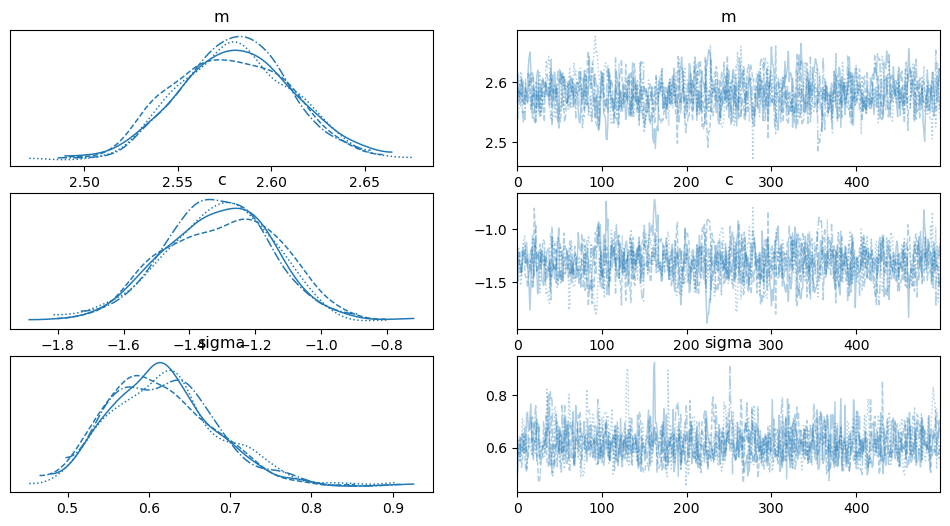

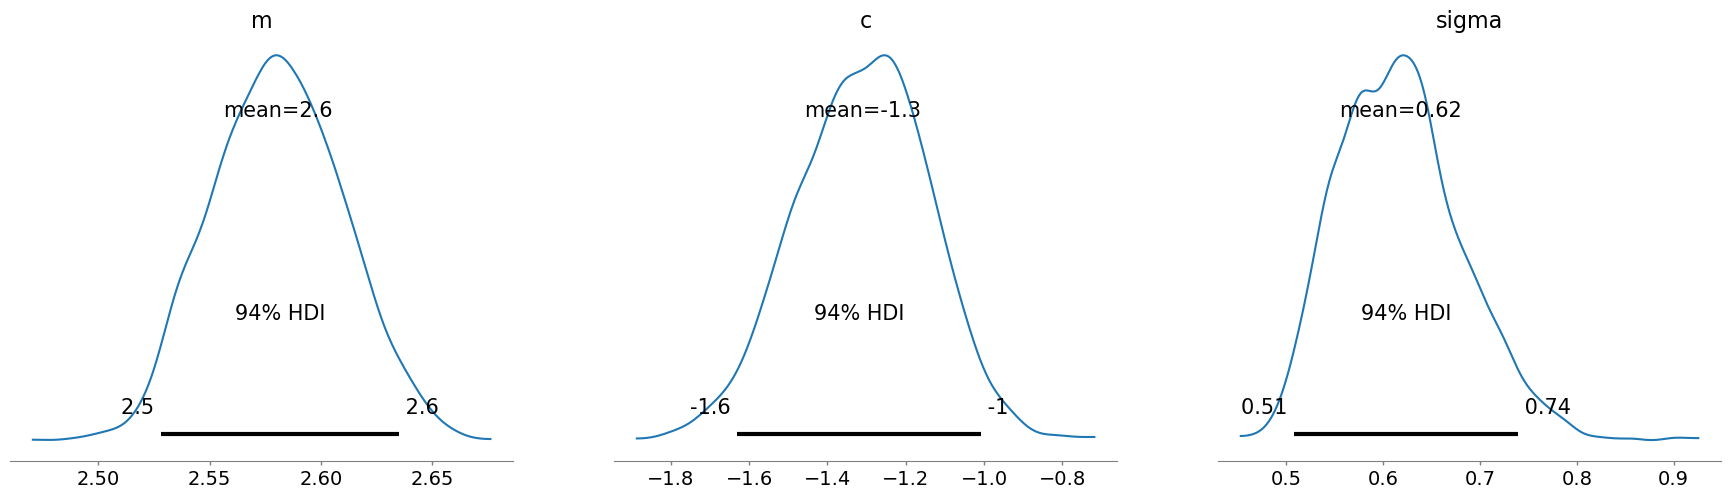

In [ ]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# ---------- data ----------
rng = np.random.default_rng(0)
x = np.linspace(0, 10, 50)
true_m, true_c, true_sigma = 2.5, -1.0, 0.7
y = true_m * x + true_c + rng.normal(0, true_sigma, size=x.size)

# ---------- model + sampling ----------
with pm.Model() as model:
    m = pm.Normal("m", mu=2, sigma=10.0)
    c = pm.Normal("c", mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal("sigma", sigma=5.0)

    mu = m * x + c
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    idata = pm.sample(target_accept=0.9, return_inferencedata=True)

# ---------- compact summary ----------
print(az.summary(idata, var_names=["m", "c", "sigma"])[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])

# If you want plots, run these separately AFTER you’re happy with speed:
az.plot_trace(idata, var_names=["m", "c", "sigma"]); plt.show()
az.plot_posterior(idata, var_names=["m", "c", "sigma"]); plt.show()


In [1]:
import pymc as pm

x_dist = pm.Normal.dist(shape=(100,3))
x_data = pm.draw(x_dist, random_seed=42)

coords = {"trial": range(100), "features": ["sunlight hours", "water amount", "soil nitrogen"]}

with pm.Model(coords=coords) as generative_model:
   x = pm.Data("x", x_data, dims=["trial", "features"])
   # Model parameters
   betas = pm.Normal("betas", dims="features")
   sigma = pm.HalfNormal("sigma")
   # Linear model
   mu = x @ betas
   # Likelihood
   # Assuming we measure deviation of each plant from baseline
   plant_growth = pm.Normal("plant growth", mu, sigma, dims="trial")

fixed_parameters = {"betas": [5, 20, 2], "sigma": 0.5}

with pm.do(generative_model, fixed_parameters) as synthetic_model:
   idata = pm.sample_prior_predictive(random_seed=42) # Sample from prior predictive distribution.
   synthetic_y = idata.prior["plant growth"].sel(draw=0, chain=0)

with pm.observe(generative_model, {"plant growth": synthetic_y}) as inference_model:
   idata = pm.sample(random_seed=42)

   summary = pm.stats.summary(idata, var_names=["betas", "sigma"])
   print(summary)

Sampling: [plant growth]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, betas]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
betas[sunlight hours]   4.972  0.054   4.875    5.079      0.001    0.001   
betas[water amount]    19.962  0.050  19.865   20.054      0.001    0.001   
betas[soil nitrogen]    1.995  0.056   1.894    2.104      0.001    0.001   
sigma                   0.512  0.038   0.442    0.580      0.001    0.001   

                       ess_bulk  ess_tail  r_hat  
betas[sunlight hours]    5459.0    3288.0    1.0  
betas[water amount]      4909.0    2852.0    1.0  
betas[soil nitrogen]     5574.0    3038.0    1.0  
sigma                    4733.0    2873.0    1.0  
